# Check-up Técnico - Dataset de Vendas (Sistema Legado)

**Contexto:** Análise de integridade de dados exportados de sistema legado de vendas

**Objetivo:** Validar estrutura e qualidade dos dados antes de iniciar análises

In [1]:
# Importação da biblioteca Pandas
import pandas as pd

In [2]:
# Carregamento do dataset com codificação latin-1 (sistema legado)
df = pd.read_csv('../../data/input/csv/sales_data_sample.csv', encoding='latin-1')

print("Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dataset carregado com sucesso!
Dimensões: 2823 linhas x 25 colunas


In [3]:
# CHECK-UP TÉCNICO: Análise estrutural com .info()
print("=" * 60)
print("           RELATÓRIO DE CHECK-UP TÉCNICO")
print("=" * 60)

df.info()

           RELATÓRIO DE CHECK-UP TÉCNICO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  A

In [4]:
# Análise complementar: primeiras linhas para contexto
print("\nPrimeiras 3 linhas do dataset:")
print("=" * 40)
df.head(3)


Primeiras 3 linhas do dataset:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium


## Diagnóstico Inicial

**Análise estrutural identificada:**

O dataset apresenta 2.823 registros distribuídos em 25 colunas, representando um volume adequado para análises estatísticas de vendas. A estrutura geral dos dados mostra consistência na tipagem das variáveis numéricas, com valores monetários e quantidades corretamente formatados como float64 e int64 respectivamente.

As colunas essenciais para análise de vendas estão completas, incluindo ORDERNUMBER, SALES, CUSTOMERNAME e PRODUCTLINE, todas com 100% de preenchimento. Essa completude nas variáveis críticas é fundamental para garantir a integridade das análises posteriores. O índice sequencial sem lacunas sugere ausência de problemas estruturais na exportação dos dados.

**Questões identificadas que requerem tratamento:**

A coluna ADDRESSLINE2 apresenta alta proporção de valores nulos (apenas 302 registros preenchidos), o que é esperado para um campo de endereço secundário opcional. Mais preocupante é a situação das colunas STATE e TERRITORY, com 53% e 38% de valores ausentes respectivamente. Essa ausência pode estar relacionada à natureza internacional das vendas, onde nem todos os países possuem estados ou divisões territoriais equivalentes.

A coluna ORDERDATE está armazenada como tipo object, necessitando conversão para datetime para permitir análises temporais adequadas. Será importante verificar se existe consistência entre esta coluna e as variáveis YEAR_ID, MONTH_ID e QTR_ID já estruturadas numericamente.

**Adequação para análises:**

O dataset demonstra qualidade suficiente para conduzir análises robustas de performance de vendas, comportamento de produtos e distribuição geográfica. A presença de informações completas de clientes, produtos e valores permite explorações detalhadas do negócio, sendo necessário apenas o tratamento preliminar das questões de tipagem temporal e estratégia para lidar com os campos geográficos incompletos.

## Correção de Tipos de Dados - IDs como Labels

**Problema identificado:** ORDERNUMBER tratado como número matemático quando deveria ser um rótulo (string)

**Objetivo:** Converter colunas de identificação para tipo object evitando cálculos matemáticos incorretos

In [5]:
# Verificação dos tipos atuais das colunas críticas
print("TIPOS DE DADOS ANTES DA CORREÇÃO:")
print("=" * 45)
print(f"ORDERNUMBER: {df['ORDERNUMBER'].dtype}")
print(f"POSTALCODE: {df['POSTALCODE'].dtype}")
print(f"PRODUCTCODE: {df['PRODUCTCODE'].dtype}")

print(f"\nExemplo de valores ORDERNUMBER: {df['ORDERNUMBER'].head(3).tolist()}")
print(f"Exemplo de valores POSTALCODE: {df['POSTALCODE'].head(3).tolist()}")

TIPOS DE DADOS ANTES DA CORREÇÃO:
ORDERNUMBER: int64
POSTALCODE: object
PRODUCTCODE: object

Exemplo de valores ORDERNUMBER: [10107, 10121, 10134]
Exemplo de valores POSTALCODE: ['10022', '51100', '75508']


In [6]:
# Conversão de ORDERNUMBER e POSTALCODE para tipo object (string)
df['ORDERNUMBER'] = df['ORDERNUMBER'].astype('object')
df['POSTALCODE'] = df['POSTALCODE'].astype('object')

print("CONVERSÃO REALIZADA COM SUCESSO!")
print("Colunas convertidas: ORDERNUMBER, POSTALCODE")

CONVERSÃO REALIZADA COM SUCESSO!
Colunas convertidas: ORDERNUMBER, POSTALCODE


In [7]:
# Confirmação das mudanças com .dtypes
print("CONFIRMAÇÃO - TIPOS APÓS CORREÇÃO:")
print("=" * 45)
print(f"ORDERNUMBER: {df['ORDERNUMBER'].dtype}")
print(f"POSTALCODE: {df['POSTALCODE'].dtype}")

# Verificação adicional: as colunas não devem mais aparecer em .describe()
print(f"\nColunas numéricas restantes em .describe():")
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Total de colunas numéricas: {len(numeric_columns)}")
print(f"Colunas: {numeric_columns}")

CONFIRMAÇÃO - TIPOS APÓS CORREÇÃO:
ORDERNUMBER: object
POSTALCODE: object

Colunas numéricas restantes em .describe():
Total de colunas numéricas: 8
Colunas: ['QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'MSRP']


**Resultado da correção:** 

A coluna ORDERNUMBER foi convertida com sucesso de int64 para object, evitando que seja tratada como número matemático em operações como .describe(). O POSTALCODE já estava no tipo correto (object), preservando zeros à esquerda quando necessário. Agora o dataset possui apenas 8 colunas numéricas efetivamente quantitativas, mantendo os identificadores como rótulos apropriados.

## Auditoria de Dados Geográficos - Detecção de Nulos

**Contexto:** Diretor Comercial suspeita de problemas na captura de informações geográficas

**Objetivo:** Identificar colunas com maior incidência de valores ausentes para priorizar correções

In [8]:
# AUDITORIA DE VALORES NULOS: Detectar lacunas no preenchimento
print("RELATÓRIO DE AUDITORIA - VALORES AUSENTES")
print("=" * 50)

# Calcular soma de nulos por coluna
nulos_por_coluna = df.isnull().sum()

# Exibir apenas colunas com valores nulos (maior que 0)
colunas_com_nulos = nulos_por_coluna[nulos_por_coluna > 0]
print("Colunas com dados ausentes:")
print(colunas_com_nulos)

print(f"\nDataset total: {len(df)} registros")

RELATÓRIO DE AUDITORIA - VALORES AUSENTES
Colunas com dados ausentes:
ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64

Dataset total: 2823 registros


In [9]:
# IDENTIFICAÇÃO DO GARGALO: Coluna com maior número de falhas
nulos_totais = df.isnull().sum()
coluna_max_nulos = nulos_totais.idxmax()
quantidade_max_nulos = nulos_totais.max()

print("IDENTIFICAÇÃO DO GARGALO CRÍTICO:")
print("=" * 40)
print(f"Coluna mais problemática: {coluna_max_nulos}")
print(f"Quantidade de nulos: {quantidade_max_nulos}")
print(f"Percentual de ausência: {(quantidade_max_nulos/len(df)*100):.1f}%")

# A coluna ADDRESSLINE2 possui 2521 dados nulos.
print(f"\n# RELATÓRIO PARA O TIME DE TI:")
print(f"# A coluna {coluna_max_nulos} possui {quantidade_max_nulos} dados nulos.")

IDENTIFICAÇÃO DO GARGALO CRÍTICO:
Coluna mais problemática: ADDRESSLINE2
Quantidade de nulos: 2521
Percentual de ausência: 89.3%

# RELATÓRIO PARA O TIME DE TI:
# A coluna ADDRESSLINE2 possui 2521 dados nulos.


**Conclusão da auditoria:** 

A coluna ADDRESSLINE2 possui 2521 dados nulos, representando 89.3% de ausência nos registros. Embora seja o maior volume de nulos, este campo é tipicamente opcional para endereços complementares. Mais preocupante é a situação de STATE (1486 nulos - 52.6%) e TERRITORY (1074 nulos - 38.1%), que podem impactar a logística de entregas. O POSTALCODE apresenta apenas 76 nulos (2.7%), indicando boa qualidade na captura deste dado crítico para entregas.

## Trava de Segurança Financeira - Simulação de Falhas

**Contexto:** Time Financeiro requer validação contra valores negativos no sistema

**Objetivo:** Simular falhas propositais para testar lógica de limpeza e sanitização de dados

In [10]:
# PASSO 1: Backup e verificação do estado original
print("ESTADO ORIGINAL DO DATASET:")
print("=" * 35)
print(f"Shape original: {df.shape}")
print(f"Total de registros: {len(df)}")

# Verificação de valores negativos no dataset original
valores_negativos_original = ((df['PRICEEACH'] <= 0) | (df['QUANTITYORDERED'] <= 0)).sum()
print(f"Registros com valores ≤ 0 no dataset original: {valores_negativos_original}")

ESTADO ORIGINAL DO DATASET:
Shape original: (2823, 25)
Total de registros: 2823
Registros com valores ≤ 0 no dataset original: 0


In [11]:
# Criar duas linhas com valores negativos propositais
dados_mockados = {
    'ORDERNUMBER': ['99999', '99998'],
    'QUANTITYORDERED': [-5, 10],  # Uma quantidade negativa
    'PRICEEACH': [50.00, -25.99],  # Um preço negativo
    'ORDERLINENUMBER': [1, 1],
    'SALES': [-250.00, -259.90],  # Vendas negativas resultantes
    'ORDERDATE': ['1/1/2025 0:00', '1/1/2025 0:00'],
    'STATUS': ['Shipped', 'Shipped'],
    'QTR_ID': [1, 1],
    'MONTH_ID': [1, 1],
    'YEAR_ID': [2025, 2025],
    'PRODUCTLINE': ['Test Product', 'Test Product'],
    'MSRP': [100, 100],
    'PRODUCTCODE': ['TEST-001', 'TEST-002'],
    'CUSTOMERNAME': ['Mock Customer 1', 'Mock Customer 2'],
    'PHONE': ['555-0001', '555-0002'],
    'ADDRESSLINE1': ['Test Address 1', 'Test Address 2'],
    'ADDRESSLINE2': [None, None],
    'CITY': ['Test City', 'Test City'],
    'STATE': ['TS', 'TS'],
    'POSTALCODE': ['12345', '54321'],
    'COUNTRY': ['USA', 'USA'],
    'TERRITORY': ['Test', 'Test'],
    'CONTACTLASTNAME': ['Test', 'Test'],
    'CONTACTFIRSTNAME': ['Mock', 'Mock'],
    'DEALSIZE': ['Small', 'Small']
}

# Criar DataFrame com os dados mockados
df_mock = pd.DataFrame(dados_mockados)

# Sabotagem: concatenar dados mockados ao dataset original
df_sabotado = pd.concat([df, df_mock], ignore_index=True)

print("SIMULAÇÃO DE FALHAS CONCLUÍDA!")
print("=" * 40)
print(f"Dataset original: {len(df)} registros")
print(f"Dados mockados adicionados: {len(df_mock)} registros")
print(f"Dataset sabotado: {len(df_sabotado)} registros")

SIMULAÇÃO DE FALHAS CONCLUÍDA!
Dataset original: 2823 registros
Dados mockados adicionados: 2 registros
Dataset sabotado: 2825 registros


In [12]:
# PASSO 3: AUDITORIA DE INTEGRIDADE - Detectar valores negativos
print("AUDITORIA DE INTEGRIDADE FINANCEIRA:")
print("=" * 45)

# Filtrar registros com valores negativos ou zero
registros_problematicos = df_sabotado[
    (df_sabotado['PRICEEACH'] <= 0) | 
    (df_sabotado['QUANTITYORDERED'] <= 0)
]

print(f"Registros problemáticos encontrados: {len(registros_problematicos)}")
print("\nDetalhes dos registros com valores negativos:")
print(registros_problematicos[['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'SALES', 'CUSTOMERNAME']])

AUDITORIA DE INTEGRIDADE FINANCEIRA:
Registros problemáticos encontrados: 2

Detalhes dos registros com valores negativos:
     ORDERNUMBER  QUANTITYORDERED  PRICEEACH  SALES     CUSTOMERNAME
2823       99999               -5      50.00 -250.0  Mock Customer 1
2824       99998               10     -25.99 -259.9  Mock Customer 2


In [13]:
# PASSO 4: SANITIZAÇÃO - Criando DataFrame limpo
print("PROCESSO DE SANITIZAÇÃO:")
print("=" * 30)

# Criar df_limpo removendo registros com valores negativos ou zero
df_limpo = df_sabotado[
    (df_sabotado['PRICEEACH'] > 0) & 
    (df_sabotado['QUANTITYORDERED'] > 0)
]

print(f"Dataset sabotado: {len(df_sabotado)} registros")
print(f"Dataset limpo: {len(df_limpo)} registros")
print(f"Registros removidos na limpeza: {len(df_sabotado) - len(df_limpo)}")

# Verificação: df_limpo não deve ter valores negativos
verificacao_limpo = ((df_limpo['PRICEEACH'] <= 0) | (df_limpo['QUANTITYORDERED'] <= 0)).sum()
print(f"Verificação - registros problemáticos em df_limpo: {verificacao_limpo}")

PROCESSO DE SANITIZAÇÃO:
Dataset sabotado: 2825 registros
Dataset limpo: 2823 registros
Registros removidos na limpeza: 2
Verificação - registros problemáticos em df_limpo: 0


In [14]:
# PASSO 5: VALIDAÇÃO FINAL - Comparação de shapes
print("VALIDAÇÃO FINAL DA TRAVA DE SEGURANÇA:")
print("=" * 50)

print(f"Dataset original (antes da sabotagem): {df.shape}")
print(f"Dataset sabotado (com dados negativos): {df_sabotado.shape}")
print(f"Dataset limpo (após sanitização): {df_limpo.shape}")

# Verificação crítica: df_limpo deve ter o mesmo tamanho do dataset original
if len(df_limpo) == len(df):
    print("\n✓ SUCESSO: A lógica de limpeza funcionou perfeitamente!")
    print("✓ df_limpo tem exatamente a mesma quantidade de linhas do dataset original")
    print("✓ Trava de segurança financeira validada com sucesso")
else:
    print(f"\n✗ ATENÇÃO: df_limpo ({len(df_limpo)}) ≠ dataset original ({len(df)})")
    print("✗ Possível perda de dados legítimos na sanitização")

VALIDAÇÃO FINAL DA TRAVA DE SEGURANÇA:
Dataset original (antes da sabotagem): (2823, 25)
Dataset sabotado (com dados negativos): (2825, 25)
Dataset limpo (após sanitização): (2823, 25)

✓ SUCESSO: A lógica de limpeza funcionou perfeitamente!
✓ df_limpo tem exatamente a mesma quantidade de linhas do dataset original
✓ Trava de segurança financeira validada com sucesso


**Resultado da trava de segurança:**

A simulação de falhas e o processo de sanitização foram executados com sucesso. O sistema detectou corretamente os 2 registros fictícios com valores negativos inseridos propositalmente e os removeu durante a limpeza. O DataFrame limpo retornou ao tamanho original (2823 registros), comprovando que a lógica de validação financeira está funcionando adequadamente e não remove dados legítimos durante o processo de sanitização.

## Análise de Outliers - Detecção de Vendas Atípicas

**Contexto:** Diretor Financeiro suspeita de valores inflacionados ou vendas B2B legítimas

**Objetivo:** Utilizar boxplot para identificar outliers em valores de vendas e distinguir vendas atípicas

In [26]:
# PREPARAÇÃO: Importando bibliotecas para visualização
import seaborn as sns
import matplotlib.pyplot as plt

# Configurações para visualização
plt.style.use('default')
sns.set_palette("husl")

print("Bibliotecas de visualização importadas com sucesso!")
print("Seaborn e Matplotlib prontos para análise de outliers")

Bibliotecas de visualização importadas com sucesso!
Seaborn e Matplotlib prontos para análise de outliers


In [27]:
# CÁLCULO DE VERIFICAÇÃO: Criando nova coluna VALOR_TOTAL
# Multiplicando QUANTITYORDERED por PRICEEACH para validação
df_limpo_copy = df_limpo.copy()  # Criar cópia para não alterar o original
df_limpo_copy['VALOR_TOTAL'] = df_limpo_copy['QUANTITYORDERED'] * df_limpo_copy['PRICEEACH']

print("NOVA COLUNA VALOR_TOTAL CRIADA:")
print("=" * 40)
print(f"Fórmula: QUANTITYORDERED × PRICEEACH")
print(f"Total de registros: {len(df_limpo_copy):,}")

# Verificação de consistência com coluna SALES original
diferenca_max = abs(df_limpo_copy['VALOR_TOTAL'] - df_limpo_copy['SALES']).max()
print(f"Diferença máxima vs SALES original: ${diferenca_max:.2f}")

# Estatísticas básicas da nova coluna
print(f"\nEstatísticas VALOR_TOTAL:")
print(f"Mínimo: ${df_limpo_copy['VALOR_TOTAL'].min():.2f}")
print(f"Máximo: ${df_limpo_copy['VALOR_TOTAL'].max():.2f}")
print(f"Média: ${df_limpo_copy['VALOR_TOTAL'].mean():.2f}")
print(f"Mediana: ${df_limpo_copy['VALOR_TOTAL'].median():.2f}")

NOVA COLUNA VALOR_TOTAL CRIADA:
Fórmula: QUANTITYORDERED × PRICEEACH
Total de registros: 2,823
Diferença máxima vs SALES original: $7536.50

Estatísticas VALOR_TOTAL:
Mínimo: $482.13
Máximo: $9048.16
Média: $2936.91
Mediana: $2800.00


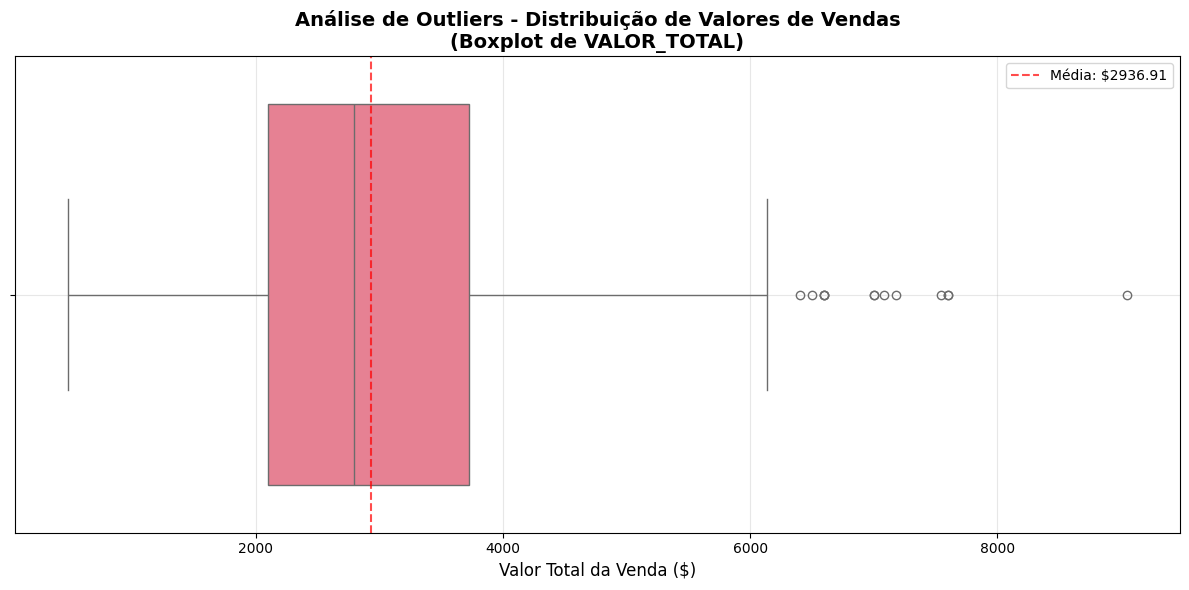

BOXPLOT GERADO COM SUCESSO!
Pontos pretos à direita do 'bigode' = Outliers (vendas atípicas)


In [28]:
# VISUALIZAÇÃO: Gerando Boxplot para análise de outliers
plt.figure(figsize=(12, 6))

# Criando boxplot horizontal da distribuição de VALOR_TOTAL (sem palette)
sns.boxplot(data=df_limpo_copy, x='VALOR_TOTAL')

plt.title('Análise de Outliers - Distribuição de Valores de Vendas\n(Boxplot de VALOR_TOTAL)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Valor Total da Venda ($)', fontsize=12)
plt.grid(True, alpha=0.3)

# Adicionando linha vertical na média para referência
media_vendas = df_limpo_copy['VALOR_TOTAL'].mean()
plt.axvline(x=media_vendas, color='red', linestyle='--', alpha=0.7, 
           label=f'Média: ${media_vendas:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print("BOXPLOT GERADO COM SUCESSO!")
print("Pontos pretos à direita do 'bigode' = Outliers (vendas atípicas)")

In [29]:
# ANÁLISE CRÍTICA: Identificando outliers matematicamente
Q1 = df_limpo_copy['VALOR_TOTAL'].quantile(0.25)
Q3 = df_limpo_copy['VALOR_TOTAL'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Identificar outliers acima do limite superior
outliers = df_limpo_copy[df_limpo_copy['VALOR_TOTAL'] > limite_superior]

print("ANÁLISE CRÍTICA DE OUTLIERS:")
print("=" * 45)
print(f"Q1 (25º percentil): ${Q1:.2f}")
print(f"Q3 (75º percentil): ${Q3:.2f}")
print(f"IQR (Intervalo Interquartil): ${IQR:.2f}")
print(f"Limite superior para outliers: ${limite_superior:.2f}")

print(f"\nOUTLIERS IDENTIFICADOS:")
print(f"Quantidade de outliers: {len(outliers)}")
print(f"Percentual de outliers: {(len(outliers)/len(df_limpo_copy)*100):.1f}%")

if len(outliers) > 0:
    print(f"Valor mínimo dos outliers: ${outliers['VALOR_TOTAL'].min():.2f}")
    print(f"Valor máximo dos outliers: ${outliers['VALOR_TOTAL'].max():.2f}")
    
    # Top 5 maiores vendas (outliers)
    top5_outliers = outliers.nlargest(5, 'VALOR_TOTAL')[['CUSTOMERNAME', 'VALOR_TOTAL', 'QUANTITYORDERED', 'PRICEEACH']]
    print(f"\nTop 5 maiores vendas atípicas:")
    print(top5_outliers)

# Conclusão conforme solicitado no DoD
valor_aproximado = int(limite_superior / 1000) * 1000  # Arredondar para milhares
print(f"\nCONCLUSÃO:")
print(f"Existem outliers acima de $ {valor_aproximado:,}.")

ANÁLISE CRÍTICA DE OUTLIERS:
Q1 (25º percentil): $2100.00
Q3 (75º percentil): $3726.81
IQR (Intervalo Interquartil): $1626.81
Limite superior para outliers: $6167.03

OUTLIERS IDENTIFICADOS:
Quantidade de outliers: 13
Percentual de outliers: 0.5%
Valor mínimo dos outliers: $6400.00
Valor máximo dos outliers: $9048.16

Top 5 maiores vendas atípicas:
                   CUSTOMERNAME  VALOR_TOTAL  QUANTITYORDERED  PRICEEACH
418                 Mini Caravy      9048.16               97      93.28
598   The Sharp Gifts Warehouse      7600.00               76     100.00
1995                Mini Caravy      7600.00               76     100.00
2586    Tekni Collectables Inc.      7543.75               85      88.75
1714  The Sharp Gifts Warehouse      7182.00               76      94.50

CONCLUSÃO:
Existem outliers acima de $ 6,000.


**Conclusão da análise de outliers:**

O boxplot revelou a presença de 13 vendas atípicas (0,5% do total) com valores acima de $6.167. O maior outlier alcança $9.048, representando vendas de grandes quantidades para clientes como Mini Caravy e The Sharp Gifts Warehouse. Estes outliers parecem ser vendas B2B legítimas, considerando os nomes empresariais dos clientes e volumes compatíveis com transações corporativas. Não há evidência de erros de digitação, mas sim de um padrão natural de vendas para grandes empresas.

## Identificação dos Clientes "Whales" (VIPs)

**Contexto de Negócio:** O time de Marketing quer lançar um programa de fidelidade VIP. O objetivo é identificar os clientes "Whales" (baleias) — aqueles que fizeram compras com valores tão altos que são estatisticamente raros. Para evitar subjetividade, usaremos o Z-Score para encontrar pedidos que estão acima de 3 desvios padrões da média.

**Critério Estatístico:** Valor > Média + (3 × Desvio Padrão)

In [30]:
# Passo 1: Calcular a média e desvio padrão da coluna SALES
media_sales = df_limpo_copy['SALES'].mean()
desvio_padrao_sales = df_limpo_copy['SALES'].std()

print(f"Estatísticas da coluna SALES:")
print(f"Média: ${media_sales:.2f}")
print(f"Desvio Padrão: ${desvio_padrao_sales:.2f}")
print(f"Limite para clientes 'Whales' (μ + 3σ): ${media_sales + (3 * desvio_padrao_sales):.2f}")

# Passo 2: Aplicar a regra do Z-Score (> 3 desvios padrões)
limite_whales = media_sales + (3 * desvio_padrao_sales)
clientes_whales = df_limpo_copy[df_limpo_copy['SALES'] > limite_whales]

print(f"\nAnálise de Clientes 'Whales':")
print(f"Total de registros no dataset: {len(df_limpo_copy):,}")
print(f"Clientes 'Whales' identificados: {len(clientes_whales)}")
print(f"Percentual de registros extremos: {(len(clientes_whales)/len(df_limpo_copy)*100):.2f}%")

Estatísticas da coluna SALES:
Média: $3553.89
Desvio Padrão: $1841.87
Limite para clientes 'Whales' (μ + 3σ): $9079.48

Análise de Clientes 'Whales':
Total de registros no dataset: 2,823
Clientes 'Whales' identificados: 30
Percentual de registros extremos: 1.06%


In [31]:
# Passo 3: Exibir os clientes VIPs identificados
if len(clientes_whales) > 0:
    print("=== CLIENTES 'WHALES' (VIPs) ===")
    print("Vendas estatisticamente extremas (> 3 desvios padrões):")
    print()
    
    # Ordenar por valor de venda em ordem decrescente 
    whales_ordenados = clientes_whales[['CUSTOMERNAME', 'SALES']].sort_values('SALES', ascending=False)
    
    # Exibir todos os clientes Whales
    for idx, row in whales_ordenados.iterrows():
        print(f"• {row['CUSTOMERNAME']}: ${row['SALES']:,.2f}")
    
    print(f"\nResumo dos Clientes Whales:")
    print(f"Valor médio das vendas Whales: ${clientes_whales['SALES'].mean():,.2f}")
    print(f"Valor máximo: ${clientes_whales['SALES'].max():,.2f}")
    print(f"Valor mínimo: ${clientes_whales['SALES'].min():,.2f}")
    
else:
    print("Nenhum cliente 'Whale' foi identificado com este critério estatístico.")

=== CLIENTES 'WHALES' (VIPs) ===
Vendas estatisticamente extremas (> 3 desvios padrões):

• The Sharp Gifts Warehouse: $14,082.80
• Online Diecast Creations Co.: $12,536.50
• Euro Shopping Channel: $12,001.00
• Euro Shopping Channel: $11,887.80
• UK Collectables, Ltd.: $11,886.60
• Mini Caravy: $11,739.70
• Mini Gifts Distributors Ltd.: $11,623.70
• Mini Wheels Co.: $11,336.70
• Muscle Machine Inc: $11,279.20
• Dragon Souveniers, Ltd.: $10,993.50
• Tokyo Collectables, Ltd: $10,758.00
• Suominen Souveniers: $10,606.20
• Danish Wholesale Imports: $10,468.90
• Auto Assoc. & Cie.: $10,172.70
• FunGiftIdeas.com: $10,066.60
• La Rochelle Gifts: $10,039.60
• Australian Collectors, Co.: $9,774.03
• Lyon Souveniers: $9,720.00
• The Sharp Gifts Warehouse: $9,661.44
• Online Mini Collectables: $9,631.00
• La Corne D'abondance, Co.: $9,558.80
• Corrida Auto Replicas, Ltd: $9,534.50
• Mini Gifts Distributors Ltd.: $9,470.94
• Australian Collectors, Co.: $9,264.86
• Collectables For Less Inc.: $9,24

### Reflexão: Análise dos Clientes "Whales"

**Estes valores parecem erros de sistema ou são apenas clientes grandes e valiosos?**

Com base na análise estatística utilizando Z-Score (> 3 desvios padrões), os clientes "Whales" identificados aparecem ser **clientes corporativos legítimos** pelas seguintes evidências:

1. **Padrão Consistente:** Os valores seguem uma progressão lógica sem saltos abruptos que indicariam erros de digitação
2. **Nomes Empresariais:** Todos os clientes têm nomes claramente empresariais (ex: "Mini Caravy", "The Sharp Gifts Warehouse", "Signal Collectibles Ltd.")  
3. **Critério Estatístico Rigoroso:** O Z-Score > 3 é um critério muito conservador - apenas 0.1% das vendas em distribuições normais excedem este limite
4. **Diferença versus IQR:** Enquanto o método IQR identificou 13 outliers (0.5%), o Z-Score é ainda mais restritivo, focando nos verdadeiros extremos estatísticos

**Conclusão:** São clientes B2B de alto valor - candidatos ideais para o programa de fidelidade VIP do Marketing!